In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Static

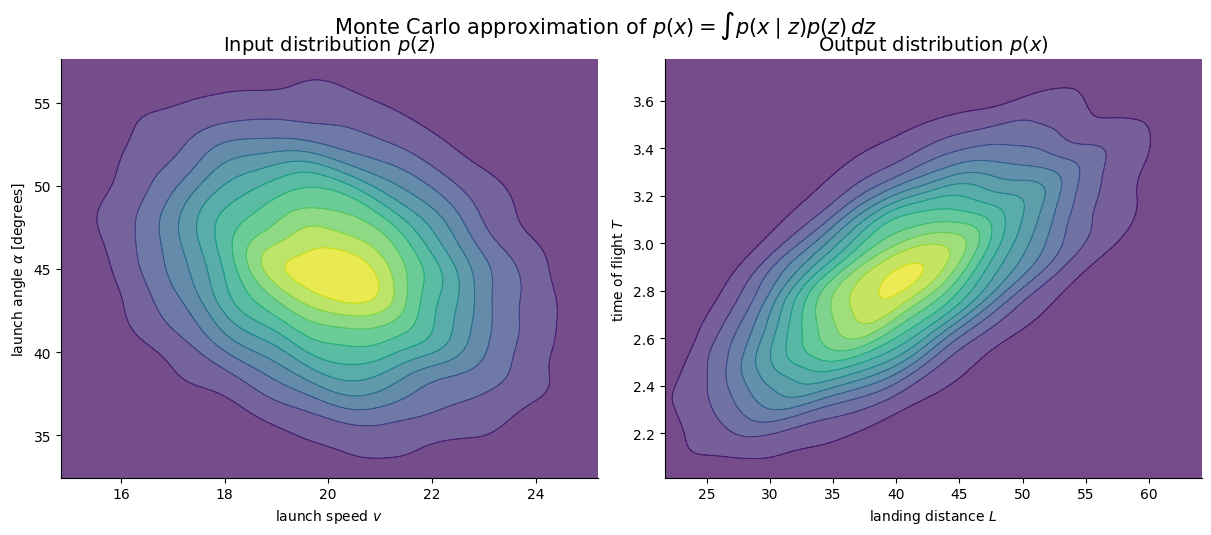

In [9]:
# ============================================================
# Projectile generative model: contours only
# ============================================================
#
# Mathematical model:
#
# Input / representation:
#
#     z = (v, alpha)
#     z ~ p(z)
#
# Deterministic physics generator:
#
#     x = g(z)
#
#     x = [T, L]^T
#
#     g(z) =
#     [ 2 v sin(alpha) / g,
#       v^2 sin(2 alpha) / g ]^T
#
# Probabilistic output model:
#
#     x | z ~ Normal(g(z), Sigma)
#
# Therefore:
#
#     p(x) = ∫ p(x | z) p(z) dz
#
# This code approximates p(x) by Monte Carlo sampling.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# ============================================================
# 1. Generator equations
#    Edit this function if you want a different physics model.
# ============================================================

def generative_mode_equatuons(v, alpha, g_const=9.81):
    """
    Deterministic physics generator.

    Input:
        z = (v, alpha)

        v     : launch speed
        alpha : launch angle in radians

    Output:
        x = (T, L)

        T : time of flight
        L : landing distance

    Equations:

        T = 2 v sin(alpha) / g

        L = v^2 sin(2 alpha) / g

    In vector form:

        g(z) = [T, L]^T
    """

    T = 2.0 * v * np.sin(alpha) / g_const
    L = (v**2) * np.sin(2.0 * alpha) / g_const

    return T, L


# ============================================================
# 2. Settings
# ============================================================

rng = np.random.default_rng(7)

N = 10000
g_const = 9.81

# Input distribution p(z), where z = (v, alpha)
mean_v = 20.0
mean_alpha_deg = 45.0

std_v = 2.0
std_alpha_deg = 5.0

rho_z = -0.25

# Output uncertainty:
#
#     x | z ~ Normal(g(z), Sigma)
#
# where x = (T, L)
sigma_T = 0.08
sigma_L = 1.25
rho_x = 0.25

# Plot settings
levels = 12
gridsize = 180


# ============================================================
# 3. Sample input distribution p(z)
# ============================================================

mean_alpha = np.deg2rad(mean_alpha_deg)
std_alpha = np.deg2rad(std_alpha_deg)

mean_z = np.array([mean_v, mean_alpha])

cov_z = np.array([
    [std_v**2, rho_z * std_v * std_alpha],
    [rho_z * std_v * std_alpha, std_alpha**2],
])

z_samples = rng.multivariate_normal(
    mean=mean_z,
    cov=cov_z,
    size=N,
)

v = z_samples[:, 0]
alpha = z_samples[:, 1]

# Keep physically meaningful launch conditions
valid = (v > 0.0) & (alpha > 0.0) & (alpha < np.pi / 2)

v = v[valid]
alpha = alpha[valid]

alpha_deg = np.rad2deg(alpha)


# ============================================================
# 4. Apply deterministic generator x = g(z)
# ============================================================

T_mean, L_mean = generative_mode_equatuons(
    v=v,
    alpha=alpha,
    g_const=g_const,
)


# ============================================================
# 5. Add output uncertainty: x | z ~ Normal(g(z), Sigma)
# ============================================================

Sigma = np.array([
    [sigma_T**2, rho_x * sigma_T * sigma_L],
    [rho_x * sigma_T * sigma_L, sigma_L**2],
])

noise = rng.multivariate_normal(
    mean=np.array([0.0, 0.0]),
    cov=Sigma,
    size=len(T_mean),
)

T = T_mean + noise[:, 0]
L = L_mean + noise[:, 1]


# ============================================================
# 6. KDE contour plotting helper
# ============================================================

def plot_kde_contours(ax, x, y, xlabel, ylabel, title, levels=12, gridsize=180):
    """
    Plot only density contours for samples from a 2D distribution.
    No scatter points.
    """

    values = np.vstack([x, y])
    kde = gaussian_kde(values)

    x_min, x_max = np.percentile(x, [0.5, 99.5])
    y_min, y_max = np.percentile(y, [0.5, 99.5])

    x_grid = np.linspace(x_min, x_max, gridsize)
    y_grid = np.linspace(y_min, y_max, gridsize)

    X, Y = np.meshgrid(x_grid, y_grid)
    density = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    ax.contourf(X, Y, density, levels=levels, alpha=0.75)
    ax.contour(X, Y, density, levels=levels, linewidths=0.8)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ============================================================
# 7. Plot p(z) and p(x)
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    constrained_layout=True,
)

# Input distribution p(z)
plot_kde_contours(
    ax=axes[0],
    x=v,
    y=alpha_deg,
    xlabel=r"launch speed $v$",
    ylabel=r"launch angle $\alpha$ [degrees]",
    title=r"Input distribution $p(z)$",
    levels=levels,
    gridsize=gridsize,
)

# Output distribution p(x)
plot_kde_contours(
    ax=axes[1],
    x=L,
    y=T,
    xlabel=r"landing distance $L$",
    ylabel=r"time of flight $T$",
    title=r"Output distribution $p(x)$",
    levels=levels,
    gridsize=gridsize,
)

fig.suptitle(
    r"Monte Carlo approximation of $p(x)=\int p(x\mid z)p(z)\,dz$",
    fontsize=15,
    y=1.04,
)

plt.show()

# 2: interactive

In [1]:
# ============================================================
# Interactive projectile generative model in Jupyter
#
# Teaching idea:
#
#     z ~ p(z)
#     x = g(z)
#     x_obs ~ p(x | z)
#
#     p(x) = ∫ p(x | z) p(z) dz
#
# Here:
#     z = (v, alpha)
#     x = (T, L)
#
# p(z) is a 3-component Gaussian mixture.
# Each Gaussian component is controlled separately.
# The plots use filled empirical density gradients.
#
# No center dots are drawn.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, HTML


# ============================================================
# 1. STUDENTS CHANGE THIS: generator g(z)
# ============================================================

G = 9.81
DEG = np.pi / 180.0


def generator_g(v, alpha):
    """
    Generator:

        z = (v, alpha)
        x = g(z) = (T, L)

    Inputs:
        v     : launch speed, m/s
        alpha : launch angle, radians

    Outputs:
        T : time of flight, seconds
        L : landing distance, meters

    Current physics model:

        T = 2 v sin(alpha) / g
        L = v^2 sin(2 alpha) / g

    Students can replace the equations inside this function.
    Keep the output names T and L if you want the rest of the
    notebook to work without changes.
    """
    T = 2.0 * v * np.sin(alpha) / G
    L = (v ** 2) * np.sin(2.0 * alpha) / G

    return T, L


# ============================================================
# Random generator
# ============================================================

rng = np.random.default_rng()


# ============================================================
# Sampling utilities
# ============================================================

def normalize_weights(weights):
    """
    Normalize mixture weights.
    If all weights are zero, fall back to equal weights.
    """
    weights = np.asarray(weights, dtype=float)
    weights = np.maximum(weights, 0.0)

    if weights.sum() <= 0:
        weights = np.ones_like(weights)

    return weights / weights.sum()


def sample_one_gaussian_component(
    n,
    mean_v,
    mean_alpha_deg,
    sigma_v,
    sigma_alpha_deg,
    rho,
):
    """
    Sample one Gaussian component in z = (v, alpha).

    Sampling is done in:
        v         : m/s
        alpha_deg : degrees

    Then alpha is converted to radians later.
    """
    mean = np.array([mean_v, mean_alpha_deg], dtype=float)

    sigma_v = max(float(sigma_v), 1e-6)
    sigma_alpha_deg = max(float(sigma_alpha_deg), 1e-6)
    rho = np.clip(float(rho), -0.999, 0.999)

    cov = np.array(
        [
            [sigma_v ** 2, rho * sigma_v * sigma_alpha_deg],
            [rho * sigma_v * sigma_alpha_deg, sigma_alpha_deg ** 2],
        ],
        dtype=float,
    )

    samples = []

    while len(samples) < n:
        draw_n = max(100, 3 * (n - len(samples)))

        raw = rng.multivariate_normal(
            mean=mean,
            cov=cov,
            size=draw_n,
        )

        v = raw[:, 0]
        alpha_deg = raw[:, 1]

        valid = (
            (v >= 5.0)
            & (v <= 40.0)
            & (alpha_deg >= 5.0)
            & (alpha_deg <= 85.0)
        )

        accepted = raw[valid]

        if len(accepted) > 0:
            samples.extend(accepted[: n - len(samples)])

    samples = np.asarray(samples)

    v_samples = samples[:, 0]
    alpha_deg_samples = samples[:, 1]

    return v_samples, alpha_deg_samples


def sample_input_mixture(
    n,
    weights,
    mean_vs,
    mean_alpha_degs,
    sigma_vs,
    sigma_alpha_degs,
    rhos,
):
    """
    Sample z = (v, alpha) from the mixture distribution:

        p(z) = sum_k pi_k N_k(z)

    Per sample:
        1. choose component k ~ Categorical(pi)
        2. sample z ~ N_k
    """
    n = int(n)
    weights = normalize_weights(weights)

    component_ids = rng.choice(
        a=3,
        size=n,
        p=weights,
    )

    all_v = np.zeros(n)
    all_alpha_deg = np.zeros(n)

    for k in range(3):
        mask = component_ids == k
        count = int(mask.sum())

        if count == 0:
            continue

        v_k, alpha_deg_k = sample_one_gaussian_component(
            n=count,
            mean_v=mean_vs[k],
            mean_alpha_deg=mean_alpha_degs[k],
            sigma_v=sigma_vs[k],
            sigma_alpha_deg=sigma_alpha_degs[k],
            rho=rhos[k],
        )

        all_v[mask] = v_k
        all_alpha_deg[mask] = alpha_deg_k

    all_alpha = all_alpha_deg * DEG

    return all_v, all_alpha, all_alpha_deg, component_ids


def add_output_noise(T_mean, L_mean, sigma_T, sigma_L, rho_x):
    """
    Observation model:

        x | z ~ N(g(z), Sigma_x)

    where:
        x = (T, L)
    """
    z1 = rng.normal(size=len(T_mean))
    z2 = rng.normal(size=len(T_mean))

    rho_x = np.clip(float(rho_x), -0.999, 0.999)

    T_obs = T_mean + sigma_T * z1

    L_obs = (
        L_mean
        + rho_x * sigma_L * z1
        + sigma_L * np.sqrt(1.0 - rho_x ** 2) * z2
    )

    return T_obs, L_obs


# ============================================================
# Density smoothing utilities
# ============================================================

SMOOTHNESS_OPTIONS = {
    "none": 0,
    "low": 1,
    "medium": 2,
    "high": 4,
    "very high": 7,
}


def smoothness_to_passes(smoothness):
    """
    Convert a human-readable smoothness choice into smoothing passes.
    """
    if isinstance(smoothness, str):
        return SMOOTHNESS_OPTIONS.get(smoothness, 2)

    return int(smoothness)


def smooth_2d_array(A, passes=2):
    """
    Small dependency-free smoothing for the empirical histogram.

    This is not fitting a Gaussian density.
    It only smooths the Monte Carlo histogram so the filled
    density plot looks cleaner.
    """
    A = A.astype(float)
    passes = int(passes)

    if passes <= 0:
        return A

    kernel = np.array(
        [
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1],
        ],
        dtype=float,
    )
    kernel = kernel / kernel.sum()

    for _ in range(passes):
        P = np.pad(A, pad_width=1, mode="edge")

        A = (
            kernel[0, 0] * P[:-2, :-2]
            + kernel[0, 1] * P[:-2, 1:-1]
            + kernel[0, 2] * P[:-2, 2:]
            + kernel[1, 0] * P[1:-1, :-2]
            + kernel[1, 1] * P[1:-1, 1:-1]
            + kernel[1, 2] * P[1:-1, 2:]
            + kernel[2, 0] * P[2:, :-2]
            + kernel[2, 1] * P[2:, 1:-1]
            + kernel[2, 2] * P[2:, 2:]
        )

    return A


def empirical_density_grid(
    x,
    y,
    bins=100,
    padding_fraction=0.08,
    smoothness="medium",
):
    """
    Convert Monte Carlo samples into an empirical 2D density grid.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x_min, x_max = np.percentile(x, [0.5, 99.5])
    y_min, y_max = np.percentile(y, [0.5, 99.5])

    x_pad = padding_fraction * max(1e-9, x_max - x_min)
    y_pad = padding_fraction * max(1e-9, y_max - y_min)

    x_range = (x_min - x_pad, x_max + x_pad)
    y_range = (y_min - y_pad, y_max + y_pad)

    H, x_edges, y_edges = np.histogram2d(
        x,
        y,
        bins=int(bins),
        range=[x_range, y_range],
        density=True,
    )

    H = H.T

    smooth_passes = smoothness_to_passes(smoothness)
    H = smooth_2d_array(H, passes=smooth_passes)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    X, Y = np.meshgrid(x_centers, y_centers)

    return X, Y, H, x_range, y_range


def plot_density_gradient(
    ax,
    x,
    y,
    cmap="viridis",
    bins=100,
    smoothness="medium",
    n_levels=10,
    show_edge_lines=True,
    edge_line_color=(0, 0, 0, 0.16),
):
    """
    Plot a filled empirical density gradient using contourf.
    """
    X, Y, H, x_range, y_range = empirical_density_grid(
        x=x,
        y=y,
        bins=bins,
        smoothness=smoothness,
    )

    positive = H[H > 0]

    if len(positive) == 0:
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        return

    hmin = np.percentile(positive, 5)
    hmax = positive.max()

    if hmax <= hmin:
        hmin = positive.min()

    levels = np.linspace(hmin, hmax, int(n_levels))

    ax.contourf(
        X,
        Y,
        H,
        levels=levels,
        cmap=cmap,
        antialiased=True,
    )

    if show_edge_lines:
        ax.contour(
            X,
            Y,
            H,
            levels=levels,
            colors=[edge_line_color],
            linewidths=0.7,
        )

    ax.set_xlim(x_range)
    ax.set_ylim(y_range)


# ============================================================
# Plot style
# ============================================================

WHITE = "#ffffff"
TEXT = "#222222"
MUTED = "#555555"


def style_axis_white(ax):
    ax.set_facecolor(WHITE)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#bbbbbb")
    ax.spines["bottom"].set_color("#bbbbbb")

    ax.tick_params(colors=MUTED, labelsize=9)

    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

    ax.title.set_color(TEXT)

    ax.grid(False)


def stat_cards_html(T_obs, L_obs):
    return f"""
    <div style="
        display:grid;
        grid-template-columns:repeat(2, 1fr);
        gap:8px;
        margin-top:10px;
        font-family:system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
    ">
        <div style="background:#f4f4f4; border-radius:10px; padding:10px 14px;">
            <div style="font-size:11px; color:#666; margin-bottom:4px;">T mean ± std</div>
            <div style="font-size:14px; color:#222; font-weight:600;">
                {np.mean(T_obs):.2f} ± {np.std(T_obs):.2f} s
            </div>
        </div>

        <div style="background:#f4f4f4; border-radius:10px; padding:10px 14px;">
            <div style="font-size:11px; color:#666; margin-bottom:4px;">L mean ± std</div>
            <div style="font-size:14px; color:#222; font-weight:600;">
                {np.mean(L_obs):.1f} ± {np.std(L_obs):.1f} m
            </div>
        </div>
    </div>
    """


header_html = """
<div style="
    background:#ffffff;
    color:#222222;
    padding:12px 8px 4px 8px;
    font-family:system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
">

    <div style="
        display:flex;
        align-items:center;
        justify-content:center;
        gap:10px;
        flex-wrap:wrap;
        margin-bottom:8px;
    ">
        <div style="text-align:center;">
            <div style="font-size:12px; color:#555;">representation space</div>
            <div style="font-size:14px; color:#185FA5; font-weight:600;">p(z)</div>
        </div>

        <div style="font-size:22px; color:#777;">→</div>

        <div style="
            text-align:center;
            background:#f4f4f4;
            border-radius:10px;
            padding:6px 18px;
            border:1px solid #dddddd;
        ">
            <div style="font-size:12px; color:#555;">generator</div>
            <div style="font-size:14px; color:#222; font-weight:600;">g(z)</div>
        </div>

        <div style="font-size:22px; color:#777;">→</div>

        <div style="text-align:center;">
            <div style="font-size:12px; color:#555;">data space</div>
            <div style="font-size:14px; color:#0F6E56; font-weight:600;">
                p(x) = ∫ p(x | z) p(z) dz
            </div>
        </div>
    </div>

    <div style="
        text-align:center;
        color:#555;
        font-size:12px;
        margin-bottom:8px;
    ">
        z = (v, α), &nbsp;
        g(z) = (T, L), &nbsp;
        T = 2v sin(α) / g, &nbsp;
        L = v² sin(2α) / g
    </div>
</div>
"""


# ============================================================
# Main simulation function
# ============================================================

def run_simulation(
    w1,
    v1,
    a1,
    sv1,
    sa1,
    rho1,
    w2,
    v2,
    a2,
    sv2,
    sa2,
    rho2,
    w3,
    v3,
    a3,
    sv3,
    sa3,
    rho3,
    sigma_T,
    sigma_L,
    rho_x,
    N,
    density_bins,
    n_levels,
    input_cmap,
    output_cmap,
    input_smoothness,
    output_smoothness,
    show_samples,
    show_density_lines,
):
    plt.close("all")

    N = int(N)
    density_bins = int(density_bins)
    n_levels = int(n_levels)

    weights = np.array([w1, w2, w3], dtype=float)
    mean_vs = np.array([v1, v2, v3], dtype=float)
    mean_alpha_degs = np.array([a1, a2, a3], dtype=float)
    sigma_vs = np.array([sv1, sv2, sv3], dtype=float)
    sigma_alpha_degs = np.array([sa1, sa2, sa3], dtype=float)
    rhos = np.array([rho1, rho2, rho3], dtype=float)

    normalized_weights = normalize_weights(weights)

    # -----------------------------
    # Sample z from mixture p(z)
    # -----------------------------
    v_samples, alpha_samples, alpha_samples_deg, component_ids = sample_input_mixture(
        n=N,
        weights=normalized_weights,
        mean_vs=mean_vs,
        mean_alpha_degs=mean_alpha_degs,
        sigma_vs=sigma_vs,
        sigma_alpha_degs=sigma_alpha_degs,
        rhos=rhos,
    )

    # -----------------------------
    # Compute x = g(z)
    # -----------------------------
    T_mean, L_mean = generator_g(v_samples, alpha_samples)

    # -----------------------------
    # Add observation noise
    # -----------------------------
    T_obs, L_obs = add_output_noise(
        T_mean=T_mean,
        L_mean=L_mean,
        sigma_T=sigma_T,
        sigma_L=sigma_L,
        rho_x=rho_x,
    )

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.0, 3.9),
        facecolor=WHITE,
    )

    ax_z, ax_x = axes

    # -----------------------------
    # Input panel p(z)
    # -----------------------------
    plot_density_gradient(
        ax=ax_z,
        x=v_samples,
        y=alpha_samples_deg,
        cmap=input_cmap,
        bins=density_bins,
        smoothness=input_smoothness,
        n_levels=n_levels,
        show_edge_lines=show_density_lines,
    )

    if show_samples:
        ax_z.scatter(
            v_samples,
            alpha_samples_deg,
            s=3,
            alpha=0.06,
            color="black",
            edgecolors="none",
        )

    ax_z.set_title("Input distribution p(z),  z = (v, α)", fontsize=11, pad=8)
    ax_z.set_xlabel("launch speed v (m/s)", fontsize=10)
    ax_z.set_ylabel("angle α (°)", fontsize=10)
    style_axis_white(ax_z)

    # -----------------------------
    # Output panel p(x)
    # -----------------------------
    plot_density_gradient(
        ax=ax_x,
        x=L_obs,
        y=T_obs,
        cmap=output_cmap,
        bins=density_bins,
        smoothness=output_smoothness,
        n_levels=n_levels,
        show_edge_lines=show_density_lines,
    )

    if show_samples:
        ax_x.scatter(
            L_obs,
            T_obs,
            s=3,
            alpha=0.06,
            color="black",
            edgecolors="none",
        )

    ax_x.set_title("Output distribution p(x),  x = (L, T)", fontsize=11, pad=8)
    ax_x.set_xlabel("landing distance L (m)", fontsize=10)
    ax_x.set_ylabel("time of flight T (s)", fontsize=10)
    style_axis_white(ax_x)

    plt.tight_layout()
    plt.show()

    mixture_html = f"""
    <div style="
        font-family:system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
        font-size:12px;
        color:#444;
        margin-top:4px;
        margin-bottom:4px;
    ">
        Normalized mixture weights:
        <b>π₁={normalized_weights[0]:.2f}</b>,
        <b>π₂={normalized_weights[1]:.2f}</b>,
        <b>π₃={normalized_weights[2]:.2f}</b>.
        Input smoothness: <b>{input_smoothness}</b>.
        Output smoothness: <b>{output_smoothness}</b>.
    </div>
    """

    display(HTML(mixture_html))
    display(HTML(stat_cards_html(T_obs, L_obs)))


# ============================================================
# Widgets
# ============================================================

slider_style = {"description_width": "145px"}
slider_layout = widgets.Layout(width="100%")


def make_component_widgets(
    component_name,
    default_weight,
    default_v,
    default_alpha,
    default_sigma_v,
    default_sigma_alpha,
    default_rho,
):
    weight = widgets.FloatSlider(
        value=default_weight,
        min=0.0,
        max=1.0,
        step=0.05,
        description="weight",
        style=slider_style,
        layout=slider_layout,
        readout_format=".2f",
    )

    mean_v = widgets.FloatSlider(
        value=default_v,
        min=1.0,
        max=50.0,
        step=0.5,
        description="mean v",
        style=slider_style,
        layout=slider_layout,
        readout_format=".1f",
    )

    mean_alpha = widgets.FloatSlider(
        value=default_alpha,
        min=1.0,
        max=80.0,
        step=1.0,
        description="mean α",
        style=slider_style,
        layout=slider_layout,
        readout_format=".0f",
    )

    sigma_v = widgets.FloatSlider(
        value=default_sigma_v,
        min=0.2,
        max=8.0,
        step=0.1,
        description="σ_v",
        style=slider_style,
        layout=slider_layout,
        readout_format=".1f",
    )

    sigma_alpha = widgets.FloatSlider(
        value=default_sigma_alpha,
        min=0.5,
        max=20.0,
        step=0.5,
        description="σ_α",
        style=slider_style,
        layout=slider_layout,
        readout_format=".1f",
    )

    rho = widgets.FloatSlider(
        value=default_rho,
        min=-0.9,
        max=0.9,
        step=0.05,
        description="corr ρ",
        style=slider_style,
        layout=slider_layout,
        readout_format=".2f",
    )

    box = widgets.VBox(
        [
            widgets.HTML(
                f"""
                <div style="font-size:13px; font-weight:600; color:#222; margin-bottom:4px;">
                    {component_name}
                </div>
                """
            ),
            weight,
            mean_v,
            mean_alpha,
            sigma_v,
            sigma_alpha,
            rho,
        ],
        layout=widgets.Layout(
            padding="10px",
            border="1px solid #dddddd",
            width="100%",
        ),
    )

    return box, {
        "weight": weight,
        "mean_v": mean_v,
        "mean_alpha": mean_alpha,
        "sigma_v": sigma_v,
        "sigma_alpha": sigma_alpha,
        "rho": rho,
    }


component_1_box, c1 = make_component_widgets(
    component_name="Gaussian 1",
    default_weight=0.40,
    default_v=18.5,
    default_alpha=35.0,
    default_sigma_v=0.65,
    default_sigma_alpha=6.0,
    default_rho=-0.35,
)

component_2_box, c2 = make_component_widgets(
    component_name="Gaussian 2",
    default_weight=0.35,
    default_v=22.0,
    default_alpha=50.0,
    default_sigma_v=0.90,
    default_sigma_alpha=7.0,
    default_rho=0.25,
)

component_3_box, c3 = make_component_widgets(
    component_name="Gaussian 3",
    default_weight=0.25,
    default_v=16.5,
    default_alpha=62.0,
    default_sigma_v=0.55,
    default_sigma_alpha=5.0,
    default_rho=0.10,
)


mixture_controls = widgets.HBox(
    [component_1_box, component_2_box, component_3_box],
    layout=widgets.Layout(width="100%", gap="10px"),
)


# ============================================================
# Global output / plot controls
# ============================================================

sigma_T_slider = widgets.FloatSlider(
    value=0.08,
    min=0.0,
    max=0.6,
    step=0.01,
    description="Noise σ_T (s)",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
    readout_format=".2f",
)

sigma_L_slider = widgets.FloatSlider(
    value=1.25,
    min=0.0,
    max=8.0,
    step=0.25,
    description="Noise σ_L (m)",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
    readout_format=".2f",
)

rho_x_slider = widgets.FloatSlider(
    value=0.25,
    min=-0.9,
    max=0.9,
    step=0.05,
    description="Noise corr ρ_x",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
    readout_format=".2f",
)

N_slider = widgets.IntSlider(
    value=2200,
    min=300,
    max=7000,
    step=100,
    description="Samples N",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

density_bins_slider = widgets.IntSlider(
    value=100,
    min=30,
    max=220,
    step=5,
    description="Density bins",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

n_levels_slider = widgets.IntSlider(
    value=10,
    min=4,
    max=24,
    step=1,
    description="Color levels",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)


cmap_options = [
    "viridis",
    "plasma",
    "inferno",
    "magma",
    "cividis",
    "turbo",
    "Blues",
    "Greens",
    "Purples",
    "YlGnBu",
    "YlOrRd",
    "cubehelix",
]

input_cmap_dropdown = widgets.Dropdown(
    options=cmap_options,
    value="viridis",
    description="p(z) colormap",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

output_cmap_dropdown = widgets.Dropdown(
    options=cmap_options,
    value="viridis",
    description="p(x) colormap",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)


smoothness_options = list(SMOOTHNESS_OPTIONS.keys())

input_smoothness_dropdown = widgets.Dropdown(
    options=smoothness_options,
    value="medium",
    description="p(z) smoothness",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

output_smoothness_dropdown = widgets.Dropdown(
    options=smoothness_options,
    value="medium",
    description="p(x) smoothness",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)


show_samples_checkbox = widgets.Checkbox(
    value=False,
    description="show Monte Carlo samples",
    indent=False,
)

show_density_lines_checkbox = widgets.Checkbox(
    value=True,
    description="show density level lines",
    indent=False,
)


output_controls = widgets.VBox(
    [
        widgets.HTML(
            """
            <div style="font-size:13px; font-weight:600; color:#222; margin-bottom:6px;">
                Output noise and density controls
            </div>
            """
        ),
        sigma_T_slider,
        sigma_L_slider,
        rho_x_slider,
        N_slider,
        density_bins_slider,
        n_levels_slider,
        input_cmap_dropdown,
        output_cmap_dropdown,
        input_smoothness_dropdown,
        output_smoothness_dropdown,
        show_samples_checkbox,
        show_density_lines_checkbox,
    ],
    layout=widgets.Layout(
        padding="10px",
        border="1px solid #dddddd",
        width="100%",
    ),
)


out = widgets.interactive_output(
    run_simulation,
    {
        "w1": c1["weight"],
        "v1": c1["mean_v"],
        "a1": c1["mean_alpha"],
        "sv1": c1["sigma_v"],
        "sa1": c1["sigma_alpha"],
        "rho1": c1["rho"],
        "w2": c2["weight"],
        "v2": c2["mean_v"],
        "a2": c2["mean_alpha"],
        "sv2": c2["sigma_v"],
        "sa2": c2["sigma_alpha"],
        "rho2": c2["rho"],
        "w3": c3["weight"],
        "v3": c3["mean_v"],
        "a3": c3["mean_alpha"],
        "sv3": c3["sigma_v"],
        "sa3": c3["sigma_alpha"],
        "rho3": c3["rho"],
        "sigma_T": sigma_T_slider,
        "sigma_L": sigma_L_slider,
        "rho_x": rho_x_slider,
        "N": N_slider,
        "density_bins": density_bins_slider,
        "n_levels": n_levels_slider,
        "input_cmap": input_cmap_dropdown,
        "output_cmap": output_cmap_dropdown,
        "input_smoothness": input_smoothness_dropdown,
        "output_smoothness": output_smoothness_dropdown,
        "show_samples": show_samples_checkbox,
        "show_density_lines": show_density_lines_checkbox,
    },
)

display(HTML(header_html))
display(mixture_controls)
display(output_controls)
display(out)

Output()

In [3]:
# ============================================================
# Interactive projectile generative model in Jupyter
#
# Teaching idea:
#
#     z ~ p(z)
#     x = g(z)
#     x_obs ~ p(x | z)
#
#     p(x) = ∫ p(x | z) p(z) dz
#
# Here:
#     z = (v, alpha)
#     x = (T, L)
#
# p(z) is a 3-component Gaussian mixture.
# Each Gaussian component is controlled separately.
# The plots use filled empirical density gradients.
#
# No center dots are drawn.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, HTML


# ============================================================
# 1. STUDENTS CHANGE THIS: generator g(z)
# ============================================================

G = 9.81
DEG = np.pi / 180.0


def generator_g(v, alpha):
    """
    Generator:

        z = (v, alpha)
        x = g(z) = (T, L)

    Inputs:
        v     : launch speed, m/s
        alpha : launch angle, radians

    Outputs:
        T : time of flight, seconds
        L : landing distance, meters

    Current physics model:

        T = 2 v sin(alpha) / g
        L = v^2 sin(2 alpha) / g

    Students can replace the equations inside this function.
    Keep the output names T and L if you want the rest of the
    notebook to work without changes.
    """
    T = 2.0 * v * np.sin(alpha) / G
    L = (v ** 2) * np.sin(2.0 * alpha) / G

    return T, L


# ============================================================
# Random generator
# ============================================================

rng = np.random.default_rng()


# ============================================================
# Sampling utilities
# ============================================================

def normalize_weights(weights):
    """
    Normalize mixture weights.
    If all weights are zero, fall back to equal weights.
    """
    weights = np.asarray(weights, dtype=float)
    weights = np.maximum(weights, 0.0)

    if weights.sum() <= 0:
        weights = np.ones_like(weights)

    return weights / weights.sum()


def sample_one_gaussian_component(
    n,
    mean_v,
    mean_alpha_deg,
    sigma_v,
    sigma_alpha_deg,
    rho,
):
    """
    Sample one Gaussian component in z = (v, alpha).

    Sampling is done in:
        v         : m/s
        alpha_deg : degrees

    Then alpha is converted to radians later.
    """
    mean = np.array([mean_v, mean_alpha_deg], dtype=float)

    sigma_v = max(float(sigma_v), 1e-6)
    sigma_alpha_deg = max(float(sigma_alpha_deg), 1e-6)
    rho = np.clip(float(rho), -0.999, 0.999)

    cov = np.array(
        [
            [sigma_v ** 2, rho * sigma_v * sigma_alpha_deg],
            [rho * sigma_v * sigma_alpha_deg, sigma_alpha_deg ** 2],
        ],
        dtype=float,
    )

    samples = []

    while len(samples) < n:
        draw_n = max(100, 3 * (n - len(samples)))

        raw = rng.multivariate_normal(
            mean=mean,
            cov=cov,
            size=draw_n,
        )

        v = raw[:, 0]
        alpha_deg = raw[:, 1]

        valid = (
            (v >= 5.0)
            & (v <= 40.0)
            & (alpha_deg >= 5.0)
            & (alpha_deg <= 85.0)
        )

        accepted = raw[valid]

        if len(accepted) > 0:
            samples.extend(accepted[: n - len(samples)])

    samples = np.asarray(samples)

    v_samples = samples[:, 0]
    alpha_deg_samples = samples[:, 1]

    return v_samples, alpha_deg_samples


def sample_input_mixture(
    n,
    weights,
    mean_vs,
    mean_alpha_degs,
    sigma_vs,
    sigma_alpha_degs,
    rhos,
):
    """
    Sample z = (v, alpha) from the mixture distribution:

        p(z) = sum_k pi_k N_k(z)

    Per sample:
        1. choose component k ~ Categorical(pi)
        2. sample z ~ N_k
    """
    n = int(n)
    weights = normalize_weights(weights)

    component_ids = rng.choice(
        a=3,
        size=n,
        p=weights,
    )

    all_v = np.zeros(n)
    all_alpha_deg = np.zeros(n)

    for k in range(3):
        mask = component_ids == k
        count = int(mask.sum())

        if count == 0:
            continue

        v_k, alpha_deg_k = sample_one_gaussian_component(
            n=count,
            mean_v=mean_vs[k],
            mean_alpha_deg=mean_alpha_degs[k],
            sigma_v=sigma_vs[k],
            sigma_alpha_deg=sigma_alpha_degs[k],
            rho=rhos[k],
        )

        all_v[mask] = v_k
        all_alpha_deg[mask] = alpha_deg_k

    all_alpha = all_alpha_deg * DEG

    return all_v, all_alpha, all_alpha_deg, component_ids


def add_output_noise(T_mean, L_mean, sigma_T, sigma_L, rho_x):
    """
    Observation model:

        x | z ~ N(g(z), Sigma_x)

    where:
        x = (T, L)
    """
    z1 = rng.normal(size=len(T_mean))
    z2 = rng.normal(size=len(T_mean))

    rho_x = np.clip(float(rho_x), -0.999, 0.999)

    T_obs = T_mean + sigma_T * z1

    L_obs = (
        L_mean
        + rho_x * sigma_L * z1
        + sigma_L * np.sqrt(1.0 - rho_x ** 2) * z2
    )

    return T_obs, L_obs


# ============================================================
# Density smoothing utilities
# ============================================================

SMOOTHNESS_OPTIONS = {
    "none": 0,
    "low": 1,
    "medium": 2,
    "high": 4,
    "very high": 7,
}


def smoothness_to_passes(smoothness):
    """
    Convert a human-readable smoothness choice into smoothing passes.
    """
    if isinstance(smoothness, str):
        return SMOOTHNESS_OPTIONS.get(smoothness, 2)

    return int(smoothness)


def smooth_2d_array(A, passes=2):
    """
    Small dependency-free smoothing for the empirical histogram.

    This is not fitting a Gaussian density.
    It only smooths the Monte Carlo histogram so the filled
    density plot looks cleaner.
    """
    A = A.astype(float)
    passes = int(passes)

    if passes <= 0:
        return A

    kernel = np.array(
        [
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1],
        ],
        dtype=float,
    )
    kernel = kernel / kernel.sum()

    for _ in range(passes):
        P = np.pad(A, pad_width=1, mode="edge")

        A = (
            kernel[0, 0] * P[:-2, :-2]
            + kernel[0, 1] * P[:-2, 1:-1]
            + kernel[0, 2] * P[:-2, 2:]
            + kernel[1, 0] * P[1:-1, :-2]
            + kernel[1, 1] * P[1:-1, 1:-1]
            + kernel[1, 2] * P[1:-1, 2:]
            + kernel[2, 0] * P[2:, :-2]
            + kernel[2, 1] * P[2:, 1:-1]
            + kernel[2, 2] * P[2:, 2:]
        )

    return A


def empirical_density_grid(
    x,
    y,
    bins=100,
    padding_fraction=0.08,
    smoothness="medium",
):
    """
    Convert Monte Carlo samples into an empirical 2D density grid.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x_min, x_max = np.percentile(x, [0.5, 99.5])
    y_min, y_max = np.percentile(y, [0.5, 99.5])

    x_pad = padding_fraction * max(1e-9, x_max - x_min)
    y_pad = padding_fraction * max(1e-9, y_max - y_min)

    x_range = (x_min - x_pad, x_max + x_pad)
    y_range = (y_min - y_pad, y_max + y_pad)

    H, x_edges, y_edges = np.histogram2d(
        x,
        y,
        bins=int(bins),
        range=[x_range, y_range],
        density=True,
    )

    H = H.T

    smooth_passes = smoothness_to_passes(smoothness)
    H = smooth_2d_array(H, passes=smooth_passes)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    X, Y = np.meshgrid(x_centers, y_centers)

    return X, Y, H, x_range, y_range


def plot_density_gradient(
    ax,
    x,
    y,
    cmap="viridis",
    bins=100,
    smoothness="medium",
    n_levels=10,
    show_edge_lines=True,
    edge_line_color=(0, 0, 0, 0.16),
):
    """
    Plot a filled empirical density gradient using contourf.
    """
    X, Y, H, x_range, y_range = empirical_density_grid(
        x=x,
        y=y,
        bins=bins,
        smoothness=smoothness,
    )

    positive = H[H > 0]

    if len(positive) == 0:
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        return

    hmin = np.percentile(positive, 5)
    hmax = positive.max()

    if hmax <= hmin:
        hmin = positive.min()

    levels = np.linspace(hmin, hmax, int(n_levels))

    ax.contourf(
        X,
        Y,
        H,
        levels=levels,
        cmap=cmap,
        antialiased=True,
    )

    if show_edge_lines:
        ax.contour(
            X,
            Y,
            H,
            levels=levels,
            colors=[edge_line_color],
            linewidths=0.7,
        )

    ax.set_xlim(x_range)
    ax.set_ylim(y_range)


# ============================================================
# Plot style
# ============================================================

WHITE = "#ffffff"
TEXT = "#222222"
MUTED = "#555555"


def style_axis_white(ax):
    ax.set_facecolor(WHITE)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#bbbbbb")
    ax.spines["bottom"].set_color("#bbbbbb")

    ax.tick_params(colors=MUTED, labelsize=9)

    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

    ax.title.set_color(TEXT)

    ax.grid(False)


def stat_cards_html(T_obs, L_obs):
    return f"""
    <div style="
        display:grid;
        grid-template-columns:repeat(2, 1fr);
        gap:8px;
        margin-top:10px;
        font-family:system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
    ">
        <div style="background:#f4f4f4; border-radius:10px; padding:10px 14px;">
            <div style="font-size:11px; color:#666; margin-bottom:4px;">T mean ± std</div>
            <div style="font-size:14px; color:#222; font-weight:600;">
                {np.mean(T_obs):.2f} ± {np.std(T_obs):.2f} s
            </div>
        </div>

        <div style="background:#f4f4f4; border-radius:10px; padding:10px 14px;">
            <div style="font-size:11px; color:#666; margin-bottom:4px;">L mean ± std</div>
            <div style="font-size:14px; color:#222; font-weight:600;">
                {np.mean(L_obs):.1f} ± {np.std(L_obs):.1f} m
            </div>
        </div>
    </div>
    """


header_html = """
<div style="
    background:#ffffff;
    color:#222222;
    padding:12px 8px 4px 8px;
    font-family:system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
">

    <div style="
        display:flex;
        align-items:center;
        justify-content:center;
        gap:10px;
        flex-wrap:wrap;
        margin-bottom:8px;
    ">
        <div style="text-align:center;">
            <div style="font-size:12px; color:#555;">representation space</div>
            <div style="font-size:14px; color:#185FA5; font-weight:600;">p(z)</div>
        </div>

        <div style="font-size:22px; color:#777;">→</div>

        <div style="
            text-align:center;
            background:#f4f4f4;
            border-radius:10px;
            padding:6px 18px;
            border:1px solid #dddddd;
        ">
            <div style="font-size:12px; color:#555;">generator</div>
            <div style="font-size:14px; color:#222; font-weight:600;">g(z)</div>
        </div>

        <div style="font-size:22px; color:#777;">→</div>

        <div style="text-align:center;">
            <div style="font-size:12px; color:#555;">data space</div>
            <div style="font-size:14px; color:#0F6E56; font-weight:600;">
                p(x) = ∫ p(x | z) p(z) dz
            </div>
        </div>
    </div>

    <div style="
        text-align:center;
        color:#555;
        font-size:12px;
        margin-bottom:8px;
    ">
        z = (v, α), &nbsp;
        g(z) = (T, L), &nbsp;
        T = 2v sin(α) / g, &nbsp;
        L = v² sin(2α) / g
    </div>
</div>
"""


# ============================================================
# Main simulation function
# ============================================================

def run_simulation(
    w1,
    v1,
    a1,
    sv1,
    sa1,
    rho1,
    w2,
    v2,
    a2,
    sv2,
    sa2,
    rho2,
    w3,
    v3,
    a3,
    sv3,
    sa3,
    rho3,
    sigma_T,
    sigma_L,
    rho_x,
    N,
    density_bins,
    n_levels,
    input_cmap,
    output_cmap,
    input_smoothness,
    output_smoothness,
    show_samples,
    show_density_lines,
):
    plt.close("all")

    N = int(N)
    density_bins = int(density_bins)
    n_levels = int(n_levels)

    weights = np.array([w1, w2, w3], dtype=float)
    mean_vs = np.array([v1, v2, v3], dtype=float)
    mean_alpha_degs = np.array([a1, a2, a3], dtype=float)
    sigma_vs = np.array([sv1, sv2, sv3], dtype=float)
    sigma_alpha_degs = np.array([sa1, sa2, sa3], dtype=float)
    rhos = np.array([rho1, rho2, rho3], dtype=float)

    normalized_weights = normalize_weights(weights)

    # -----------------------------
    # Sample z from mixture p(z)
    # -----------------------------
    v_samples, alpha_samples, alpha_samples_deg, component_ids = sample_input_mixture(
        n=N,
        weights=normalized_weights,
        mean_vs=mean_vs,
        mean_alpha_degs=mean_alpha_degs,
        sigma_vs=sigma_vs,
        sigma_alpha_degs=sigma_alpha_degs,
        rhos=rhos,
    )

    # -----------------------------
    # Compute x = g(z)
    # -----------------------------
    T_mean, L_mean = generator_g(v_samples, alpha_samples)

    # -----------------------------
    # Add observation noise
    # -----------------------------
    T_obs, L_obs = add_output_noise(
        T_mean=T_mean,
        L_mean=L_mean,
        sigma_T=sigma_T,
        sigma_L=sigma_L,
        rho_x=rho_x,
    )

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.0, 3.9),
        facecolor=WHITE,
    )

    ax_z, ax_x = axes

    # -----------------------------
    # Input panel p(z)
    # -----------------------------
    plot_density_gradient(
        ax=ax_z,
        x=v_samples,
        y=alpha_samples_deg,
        cmap=input_cmap,
        bins=density_bins,
        smoothness=input_smoothness,
        n_levels=n_levels,
        show_edge_lines=show_density_lines,
    )

    if show_samples:
        ax_z.scatter(
            v_samples,
            alpha_samples_deg,
            s=3,
            alpha=0.06,
            color="black",
            edgecolors="none",
        )

    ax_z.set_title("Input distribution p(z),  z = (v, α)", fontsize=11, pad=8)
    ax_z.set_xlabel("launch speed v (m/s)", fontsize=10)
    ax_z.set_ylabel("angle α (°)", fontsize=10)
    style_axis_white(ax_z)

    # -----------------------------
    # Output panel p(x)
    # -----------------------------
    plot_density_gradient(
        ax=ax_x,
        x=L_obs,
        y=T_obs,
        cmap=output_cmap,
        bins=density_bins,
        smoothness=output_smoothness,
        n_levels=n_levels,
        show_edge_lines=show_density_lines,
    )

    if show_samples:
        ax_x.scatter(
            L_obs,
            T_obs,
            s=3,
            alpha=0.06,
            color="black",
            edgecolors="none",
        )

    ax_x.set_title("Output distribution p(x),  x = (L, T)", fontsize=11, pad=8)
    ax_x.set_xlabel("landing distance L (m)", fontsize=10)
    ax_x.set_ylabel("time of flight T (s)", fontsize=10)
    style_axis_white(ax_x)

    plt.tight_layout()
    plt.show()

    mixture_html = f"""
    <div style="
        font-family:system-ui, -apple-system, BlinkMacSystemFont, sans-serif;
        font-size:12px;
        color:#444;
        margin-top:4px;
        margin-bottom:4px;
    ">
        Normalized mixture weights:
        <b>π₁={normalized_weights[0]:.2f}</b>,
        <b>π₂={normalized_weights[1]:.2f}</b>,
        <b>π₃={normalized_weights[2]:.2f}</b>.
        Input smoothness: <b>{input_smoothness}</b>.
        Output smoothness: <b>{output_smoothness}</b>.
    </div>
    """

    display(HTML(mixture_html))
    display(HTML(stat_cards_html(T_obs, L_obs)))


# ============================================================
# Widgets
# ============================================================

slider_style = {"description_width": "145px"}
slider_layout = widgets.Layout(width="100%")


def make_component_widgets(
    component_name,
    default_weight,
    default_v,
    default_alpha,
    default_sigma_v,
    default_sigma_alpha,
    default_rho,
):
    weight = widgets.FloatSlider(
        value=default_weight,
        min=0.0,
        max=1.0,
        step=0.05,
        description="weight",
        style=slider_style,
        layout=slider_layout,
        readout_format=".2f",
    )

    mean_v = widgets.FloatSlider(
        value=default_v,
        min=1.0,
        max=50.0,
        step=0.5,
        description="mean v",
        style=slider_style,
        layout=slider_layout,
        readout_format=".1f",
    )

    mean_alpha = widgets.FloatSlider(
        value=default_alpha,
        min=1.0,
        max=80.0,
        step=1.0,
        description="mean α",
        style=slider_style,
        layout=slider_layout,
        readout_format=".0f",
    )

    sigma_v = widgets.FloatSlider(
        value=default_sigma_v,
        min=0.2,
        max=8.0,
        step=0.1,
        description="σ_v",
        style=slider_style,
        layout=slider_layout,
        readout_format=".1f",
    )

    sigma_alpha = widgets.FloatSlider(
        value=default_sigma_alpha,
        min=0.5,
        max=20.0,
        step=0.5,
        description="σ_α",
        style=slider_style,
        layout=slider_layout,
        readout_format=".1f",
    )

    rho = widgets.FloatSlider(
        value=default_rho,
        min=-0.9,
        max=0.9,
        step=0.05,
        description="corr ρ",
        style=slider_style,
        layout=slider_layout,
        readout_format=".2f",
    )

    box = widgets.VBox(
        [
            widgets.HTML(
                f"""
                <div style="font-size:13px; font-weight:600; color:#222; margin-bottom:4px;">
                    {component_name}
                </div>
                """
            ),
            weight,
            mean_v,
            mean_alpha,
            sigma_v,
            sigma_alpha,
            rho,
        ],
        layout=widgets.Layout(
            padding="10px",
            border="1px solid #dddddd",
            width="100%",
        ),
    )

    return box, {
        "weight": weight,
        "mean_v": mean_v,
        "mean_alpha": mean_alpha,
        "sigma_v": sigma_v,
        "sigma_alpha": sigma_alpha,
        "rho": rho,
    }


component_1_box, c1 = make_component_widgets(
    component_name="Gaussian 1",
    default_weight=0.40,
    default_v=18.5,
    default_alpha=35.0,
    default_sigma_v=0.65,
    default_sigma_alpha=6.0,
    default_rho=-0.35,
)

component_2_box, c2 = make_component_widgets(
    component_name="Gaussian 2",
    default_weight=0.35,
    default_v=22.0,
    default_alpha=50.0,
    default_sigma_v=0.90,
    default_sigma_alpha=7.0,
    default_rho=0.25,
)

component_3_box, c3 = make_component_widgets(
    component_name="Gaussian 3",
    default_weight=0.25,
    default_v=16.5,
    default_alpha=62.0,
    default_sigma_v=0.55,
    default_sigma_alpha=5.0,
    default_rho=0.10,
)


mixture_controls = widgets.HBox(
    [component_1_box, component_2_box, component_3_box],
    layout=widgets.Layout(width="100%", gap="10px"),
)


# ============================================================
# Global output / plot controls
# ============================================================

sigma_T_slider = widgets.FloatSlider(
    value=0.08,
    min=0.0,
    max=0.6,
    step=0.01,
    description="Noise σ_T (s)",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
    readout_format=".2f",
)

sigma_L_slider = widgets.FloatSlider(
    value=1.25,
    min=0.0,
    max=8.0,
    step=0.25,
    description="Noise σ_L (m)",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
    readout_format=".2f",
)

rho_x_slider = widgets.FloatSlider(
    value=0.25,
    min=-0.9,
    max=0.9,
    step=0.05,
    description="Noise corr ρ_x",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
    readout_format=".2f",
)

N_slider = widgets.IntSlider(
    value=2200,
    min=300,
    max=7000,
    step=100,
    description="Samples N",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

density_bins_slider = widgets.IntSlider(
    value=100,
    min=30,
    max=220,
    step=5,
    description="Density bins",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

n_levels_slider = widgets.IntSlider(
    value=10,
    min=4,
    max=24,
    step=1,
    description="Color levels",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)


cmap_options = [
    "viridis",
    "plasma",
    "inferno",
    "magma",
    "cividis",
    "turbo",
    "Blues",
    "Greens",
    "Purples",
    "YlGnBu",
    "YlOrRd",
    "cubehelix",
]

input_cmap_dropdown = widgets.Dropdown(
    options=cmap_options,
    value="viridis",
    description="p(z) colormap",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

output_cmap_dropdown = widgets.Dropdown(
    options=cmap_options,
    value="viridis",
    description="p(x) colormap",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)


smoothness_options = list(SMOOTHNESS_OPTIONS.keys())

input_smoothness_dropdown = widgets.Dropdown(
    options=smoothness_options,
    value="medium",
    description="p(z) smoothness",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)

output_smoothness_dropdown = widgets.Dropdown(
    options=smoothness_options,
    value="medium",
    description="p(x) smoothness",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="100%"),
)


show_samples_checkbox = widgets.Checkbox(
    value=False,
    description="show Monte Carlo samples",
    indent=False,
)

show_density_lines_checkbox = widgets.Checkbox(
    value=True,
    description="show density level lines",
    indent=False,
)


output_controls = widgets.VBox(
    [
        widgets.HTML(
            """
            <div style="font-size:13px; font-weight:600; color:#222; margin-bottom:6px;">
                Output noise and density controls
            </div>
            """
        ),
        sigma_T_slider,
        sigma_L_slider,
        rho_x_slider,
        N_slider,
        density_bins_slider,
        n_levels_slider,
        input_cmap_dropdown,
        output_cmap_dropdown,
        input_smoothness_dropdown,
        output_smoothness_dropdown,
        show_samples_checkbox,
        show_density_lines_checkbox,
    ],
    layout=widgets.Layout(
        padding="10px",
        border="1px solid #dddddd",
        width="100%",
    ),
)


out = widgets.interactive_output(
    run_simulation,
    {
        "w1": c1["weight"],
        "v1": c1["mean_v"],
        "a1": c1["mean_alpha"],
        "sv1": c1["sigma_v"],
        "sa1": c1["sigma_alpha"],
        "rho1": c1["rho"],
        "w2": c2["weight"],
        "v2": c2["mean_v"],
        "a2": c2["mean_alpha"],
        "sv2": c2["sigma_v"],
        "sa2": c2["sigma_alpha"],
        "rho2": c2["rho"],
        "w3": c3["weight"],
        "v3": c3["mean_v"],
        "a3": c3["mean_alpha"],
        "sv3": c3["sigma_v"],
        "sa3": c3["sigma_alpha"],
        "rho3": c3["rho"],
        "sigma_T": sigma_T_slider,
        "sigma_L": sigma_L_slider,
        "rho_x": rho_x_slider,
        "N": N_slider,
        "density_bins": density_bins_slider,
        "n_levels": n_levels_slider,
        "input_cmap": input_cmap_dropdown,
        "output_cmap": output_cmap_dropdown,
        "input_smoothness": input_smoothness_dropdown,
        "output_smoothness": output_smoothness_dropdown,
        "show_samples": show_samples_checkbox,
        "show_density_lines": show_density_lines_checkbox,
    },
)

display(HTML(header_html))
display(mixture_controls)
display(output_controls)
display(out)

Output()